# Вариант №8 - Источник №2

In [ ]:
!pip install pymorphy3 nltk -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 19.4 MB/s eta 0:00:00


In [ ]:
# ============================================================
# ПРОЕКТ: Обработка текста Налогового кодекса РФ, часть первая
# Источник: страницы ConsultantPlus
# Задача:
# 1) скачать страницы;
# 2) извлечь только смысловой текст статей;
# 3) убрать заголовки, редакционные примечания, подписи, содержание;
# 4) подготовить текст к анализу;
# 5) построить график роста словаря;
# 6) найти примерные места резкого прироста словаря.
# ============================================================


# -----------------------------
# 1. Импорт библиотек
# -----------------------------

import re
import time
import csv
from pathlib import Path
from collections import Counter

import requests
import pandas as pd
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

import pymorphy3


# -----------------------------
# 2. Первичная настройка
# -----------------------------

BASE_URL = "https://www.consultant.ru"

# Главная страница документа.
START_URL = "https://www.consultant.ru/document/cons_doc_LAW_19671/"

# Папка для результатов
OUTPUT_DIR = Path("nk_rf_results")
OUTPUT_DIR.mkdir(exist_ok=True)

RAW_TEXT_FILE = OUTPUT_DIR / "01_raw_text.txt"
CLEAN_TEXT_FILE = OUTPUT_DIR / "02_clean_text.txt"
LEMMAS_FILE = OUTPUT_DIR / "03_lemmas.txt"
VOCAB_GROWTH_CSV = OUTPUT_DIR / "04_vocab_growth.csv"
VOCAB_JUMPS_CSV = OUTPUT_DIR / "05_vocab_jumps.csv"
VOCAB_GROWTH_PNG = OUTPUT_DIR / "06_vocab_growth_plot.png"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0 Safari/537.36"
    )
}

REQUEST_TIMEOUT = 20
PAUSE_BETWEEN_REQUESTS = 1.0

morph = pymorphy3.MorphAnalyzer()

russian_stopwords = set(stopwords.words("russian"))

# Дополнительные стоп-слова, которые часто встречаются в юридических текстах,
# но не всегда полезны для анализа словаря.
extra_stopwords = {
    "это", "который", "также", "иной", "иный", "данный",
    "настоящий", "соответствующий", "указанный", "такой",
    "часть", "статья", "глава", "раздел", "пункт", "подпункт",
    "кодекс", "федеральный", "закон", "российский", "федерация",
    "рф", "нк", "никакой", "какой", "либо", "свой", "каждый", "любой", "оно", "чей", "самый", "всякий", "какой",
}
currency_stopwords = {
    "рубль",
    "копейка",
    "доллар",
    "евро",
    "фунт",
    "стерлинг",
    "иена",
    "юань",
    "франк",
    "крона",
    "лира",
    "тенге",
    "гривна",
    "белорусский",
    "злотый",
    "рупия",
    "дирхам",
    "сом",
    "манат",
}
all_stopwords = russian_stopwords | extra_stopwords | currency_stopwords

def is_number_related_word(word: str, lemma: str, parsed) -> bool:
    """
    Проверяет, связано ли слово с числом.

    Удаляет:
    - обычные числительные: пять, пяти, пятый, пятого;
    - числительные, которые pymorphy определяет как NUMR;
    - слова с числовыми корнями: дважды, трижды, двукратный,
      трехкратный, четырехкратный и похожие.
    """

    # 1. Обычные числительные по морфологическому тегу:
    # пять, пяти, пятью, двести, первый, второго и т.п.
    if "NUMR" in parsed.tag:
        return True

    # 2. На всякий случай проверяем нормальную форму.
    # Иногда полезно, если исходная форма была склонённой.
    parsed_lemma = morph.parse(lemma)[0]
    if "NUMR" in parsed_lemma.tag:
        return True

    # 3. Слова, связанные с числом, но не являющиеся обычными числительными:
    # Порядковые числительные
    ordinal_lemmas = {
        "первый", "второй", "третий", "четвертый", "пятый",
        "шестой", "седьмой", "восьмой", "девятый", "десятый",
        "одиннадцатый", "двенадцатый", "тринадцатый", "четырнадцатый",
        "пятнадцатый", "шестнадцатый", "семнадцатый", "восемнадцатый",
        "девятнадцатый", "двадцатый", "тридцатый", "сороковой",
        "пятидесятый", "шестидесятый", "семидесятый", "восьмидесятый",
        "девяностый", "сотый", "тысячный", "миллионный", "ноль", "единица",
        "десяток", "сотня", "тысяча", "миллион", "миллиард", "триллион", "единица", "двойка", "тройка", "четверка", "пятерка", "шестерка", "семерка", "восьмерка", "девятка"
    }

    if lemma in ordinal_lemmas:
        return True
    for i in ordinal_lemmas:
      if i in lemma or i in word:
        return True

    # 4. Отдельно ловим слова с частью "-кратн-":
    # двукратный, трехкратный, пятикратный, многократный.
    if "кратн" in word or "кратн" in lemma or "сотый" in lemma or "тысячный" in lemma:
        return True

    return False

def is_proper_name(word: str, lemma: str, parsed) -> bool:
    """
    Проверяет, является ли слово именем собственным:
    имя, фамилия, отчество, географическое название,
    организация или торговая марка.
    """

    proper_name_tags = {"Name", "Surn", "Patr", "Geox", "Orgn", "Trad"}

    # Проверяем теги исходного слова
    if any(tag in parsed.tag for tag in proper_name_tags):
        return True

    # Дополнительно проверяем теги леммы
    parsed_lemma = morph.parse(lemma)[0]
    if any(tag in parsed_lemma.tag for tag in proper_name_tags):
        return True

    return False
# ============================================================
# 3. Функции скачивания HTML
# ============================================================

def download_html(url: str) -> str:
    """
    Скачивает HTML страницы.
    Возвращает HTML в виде строки.
    """
    response = requests.get(
        url,
        headers=HEADERS,
        timeout=REQUEST_TIMEOUT
    )
    response.raise_for_status()
    response.encoding = "utf-8"
    return response.text


def save_debug_html(html: str, filename: str) -> None:
    """
    Сохраняет HTML для проверки, если нужно посмотреть структуру страницы.
    """
    path = OUTPUT_DIR / filename
    path.write_text(html, encoding="utf-8")


# ============================================================
# 4. Поиск ссылок на страницы статей
# ============================================================

def normalize_url(href: str) -> str | None:
    """
    Превращает относительную ссылку в полную.
    """
    if not href:
        return None

    if href.startswith("http"):
        return href

    if href.startswith("/"):
        return BASE_URL + href

    return None


def collect_document_links(start_url: str) -> list[str]:
    """
    Собирает ссылки на страницы внутри документа.

    В ConsultantPlus ссылки на статьи обычно выглядят так:
    /document/cons_doc_LAW_19671/какой-то-хэш/

    Поэтому берём ссылки, которые:
    1) относятся к этому же документу cons_doc_LAW_19671;
    2) не являются якорями;
    3) не являются служебными ссылками.
    """
    html = download_html(start_url)
    save_debug_html(html, "debug_start_page.html")

    soup = BeautifulSoup(html, "html.parser")

    links = []

    for a in soup.find_all("a", href=True):
        href = a.get("href")
        full_url = normalize_url(href)

        if not full_url:
            continue

        if "/document/cons_doc_LAW_19671/" not in full_url:
            continue

        if "#" in full_url:
            full_url = full_url.split("#")[0]

        links.append(full_url)


    # Убираем дубли, сохраняя порядок
    unique_links = list(dict.fromkeys(links))
    return unique_links


# ============================================================
# 5. Извлечение смыслового текста из HTML страницы
# ============================================================

def remove_service_blocks(content) -> None:
    """
    Удаляет из основного блока документа всё, что не является смысловым текстом.

    По твоему HTML видно, что надо удалить:
    - заголовки h1, h2, h3;
    - блоки doc-style, где лежат названия статей/глав;
    - блоки doc-edit, где указаны редакции законов;
    - блоки doc-insert, где указаны предыдущие редакции;
    - пустые элементы;
    - ссылки-якоря без текста.
    """

    selectors_to_remove = [
        "h1",
        "h2",
        "h3",
        "h4",
        ".document__style",
        ".doc-style",
        ".document__edit",
        ".doc-edit",
        ".document__insert",
        ".doc-insert",
        ".notes",
        ".document-page__notes",
        ".full-text",
        "script",
        "style",
        "noscript",
        "button",
        "svg"
    ]

    for selector in selectors_to_remove:
        for tag in content.select(selector):
            tag.decompose()

    # Удаляем якоря вида <a id="dst..."></a>,
    # чтобы они не мешали тексту.
    for a in content.find_all("a"):
        if not a.get_text(strip=True):
            a.decompose()
        else:
            # Если ссылка содержит обычный текст, например "закона",
            # оставляем сам текст, но убираем HTML-обёртку ссылки.
            a.unwrap()


def extract_meaningful_text_from_html(html: str) -> str:
    """
    Извлекает только смысловой текст статьи из HTML страницы.

    Главная идея:
    берём только div.document-page__content,
    потому что в нём находится текст статьи.

    Всё остальное — меню, футер, SEO-ссылки, новости,
    подписи снизу страницы, хлебные крошки — не берём вообще.
    """
    soup = BeautifulSoup(html, "html.parser")

    content = soup.select_one("div.document-page__content")

    if content is None:
        return ""

    remove_service_blocks(content)

    text = content.get_text(separator="\n", strip=True)

    return text


# ============================================================
# 6. Дополнительная чистка сырого текста
# ============================================================

def fix_hyphenated_line_break(match):
    left = match.group(1)
    right = match.group(2)

    without_hyphen = left + right
    with_hyphen = left + "-" + right

    parsed_without = morph.parse(without_hyphen.lower())[0]

    # Если слитное слово известно анализатору,
    # считаем, что это обычный перенос слова:
    # налого-
    # плательщик -> налогоплательщик
    if getattr(parsed_without, "is_known", False):
        return without_hyphen

    # Если слитное слово неизвестно,
    # сохраняем дефис:
    # фото-
    # киносъемка -> фото-киносъемка
    return with_hyphen

def fix_broken_words(text: str) -> str:
    """
    Исправляет слова, разбитые переносами.
    Без ручного списка слов:
    - если слитное слово известно pymorphy, убирает дефис;
    - если слитное слово неизвестно, сохраняет дефис.
    """

    # Нормализуем разные виды тире к обычному дефису
    text = text.replace("–", "-").replace("—", "-")

    # 1. Случай: фото- киносъемка
    text = re.sub(
        r"([А-Яа-яЁё]+)-\s+([А-Яа-яЁё]+)",
        fix_hyphenated_line_break,
        text
    )

    # 2. Случай:
    # фото-
    # киносъемка
    pattern = r"([А-Яа-яЁё]+)-\s*\n\s*([А-Яа-яЁё]+)"

    previous_text = None
    while previous_text != text:
        previous_text = text
        text = re.sub(
            pattern,
            fix_hyphenated_line_break,
            text
        )

    return text


def remove_document_structure_lines(text: str) -> str:
    """
    Удаляет строки, похожие на названия глав, разделов, статей,
    а также служебные подписи и содержание.

    Важно:
    заголовки статей уже удаляются на HTML-уровне,
    но эта функция нужна как дополнительная страховка.
    """

    cleaned_lines = []

    for line in text.splitlines():
        line = line.strip()

        if not line:
            continue

        # Убираем строки типа:
        # "НК РФ Статья 1. ..."
        if re.match(r"^НК\s+РФ\s+Статья\s+\d+", line, flags=re.IGNORECASE):
            continue

        # Убираем строки типа:
        # "Статья 1. ..."
        if re.match(r"^Статья\s+\d+(\.\d+)?\.", line, flags=re.IGNORECASE):
            continue

        # Убираем строки типа:
        # "Глава 1. ..."
        if re.match(r"^Глава\s+\d+(\.\d+)?\.", line, flags=re.IGNORECASE):
            continue

        # Убираем строки типа:
        # "Раздел I. ..."
        if re.match(r"^Раздел\s+[IVXLCDM\d]+", line, flags=re.IGNORECASE):
            continue

        # Убираем строки содержания
        if re.match(r"^Содержание$", line, flags=re.IGNORECASE):
            continue

        # Убираем строки с редакционными пометками,
        # если они вдруг остались после HTML-чистки.
        service_patterns = [
            r"^\(в ред\.",
            r"^\(см\. текст в предыдущей",
            r"^\(п\.\s*\d+",
            r"^\(абзац",
            r"утратил силу",
            r"КонсультантПлюс",
            r"Все права защищены",
            r"Открыть полный текст документа",
            r"Комментарии к статье",
            r"См\. также"
        ]

        if any(re.search(pattern, line, flags=re.IGNORECASE) for pattern in service_patterns):
            continue

        cleaned_lines.append(line)

    return "\n".join(cleaned_lines)


def normalize_raw_text(text: str) -> str:
    """
    Нормализует сырой смысловой текст:
    - убирает структурные строки;
    - приводит пробелы в нормальный вид.
    """

    text = remove_document_structure_lines(text)

    # Убираем лишние пробелы внутри строк
    text = re.sub(r"[ \t]+", " ", text)

    # Убираем слишком большое количество пустых строк
    text = re.sub(r"\n{2,}", "\n", text)

    return text.strip()


# ============================================================
# 7. Подготовка текста к анализу
# ============================================================

def clean_text_for_analysis(text: str) -> str:
    """
    Очищает текст для анализа, но сохраняет регистр.
    Это важно для более точного определения имен собственных.
    - чинит разбитые слова;
    """

    text = text.replace("ё", "е").replace("Ё", "Е")

    # Оставляем только русские буквы, дефисы и пробелы
    text = re.sub(r"[^А-Яа-я\-\s]", " ", text)

    # Удаляем одиночные буквы
    text = re.sub(r"\b[А-Яа-я]\b", " ", text)

    # Убираем лишние пробелы
    text = re.sub(r"\s+", " ", text)

    text = fix_broken_words(text)

    return text.strip()

def tokenize_lemmatize_with_source_positions(text: str) -> pd.DataFrame:
    """
    Разбивает исходный текст на слова, лемматизирует их,
    фильтрует,
    и сохраняет положение каждого оставшегося слова
    в исходном тексте.

    Сохраняются два типа координат:
    - line_number и column_number: номер строки и номер символа в строке;
    - char_start и char_end: глобальные индексы символов в исходном тексте.
      Они нужны для функции extract_jump_contexts().
    """

    rows = []
    lemma_index = 0
    global_offset = 0

    for line_number, line_with_ending in enumerate(text.splitlines(keepends=True), start=1):
        line = line_with_ending.rstrip("\r\n")

        for match in re.finditer(r"[А-Яа-яЁё-]+", line):

            original_word = match.group(0)
            word_lower = original_word.lower()

            if word_lower in all_stopwords:
                continue

            parsed = morph.parse(original_word)[0]
            lemma = parsed.normal_form.lower()

            if re.fullmatch(r"[А-ЯЁ]{2,}", original_word) is not None:
                continue

            if is_number_related_word(word_lower, lemma, parsed):
                continue

            if is_proper_name(original_word, lemma, parsed):
                continue

            if lemma in all_stopwords:
                continue

            if word_lower.startswith("-") or word_lower.endswith("-"):
                continue

            if "-" in lemma:
                first_part = lemma.split("-")[0]
                if first_part in all_stopwords:
                    continue

            if len(lemma) < 3:
                continue

            lemma_index += 1

            rows.append({
                "lemma_index": lemma_index,
                "lemma": lemma,
                "original": original_word,

                "line_number": line_number,
                "column_number": match.start() + 1,
                "line_text": line,

                "char_start": global_offset + match.start(),
                "char_end": global_offset + match.end()
            })

        global_offset += len(line_with_ending)

    return pd.DataFrame(rows)

# ============================================================
# 8. Анализ роста словаря
# ============================================================

def calculate_vocab_growth(lemmas: list[str], step: int = 500) -> pd.DataFrame:
    """
    Считает, как растёт словарь документа.

    step = 500 означает:
    каждые 500 лемм проверяем,
    сколько уникальных лемм накопилось.

    Дополнительно считается скорость роста словаря
    """

    seen_words = set()
    rows = []

    for i, lemma in enumerate(lemmas, start=1):
        seen_words.add(lemma)

        if i % step == 0 or i == len(lemmas):
            rows.append({
                "position": i,
                "vocabulary_size": len(seen_words)
            })

    df = pd.DataFrame(rows)

    if df.empty:
        return pd.DataFrame(
            columns=[
                "position",
                "vocabulary_size",
                "vocab_increase",
                "position_step",
                "vocab_speed"
            ]
        )

    # Прирост словаря между соседними точками
    df["vocab_increase"] = df["vocabulary_size"].diff().fillna(df["vocabulary_size"])

    # Размер интервала между соседними позициями
    df["position_step"] = df["position"].diff().fillna(df["position"])

    # Скорость роста словаря:
    # сколько новых уникальных лемм появляется на один шаг анализа
    df["vocab_speed"] = df["vocab_increase"] / df["position_step"] * step

    return df



def add_adaptive_threshold(
    vocab_df: pd.DataFrame,
    window: int = 3,
    multiplier: float = 1.0,
    min_vocab_speed: float = 1.0,
    exclude_initial_steps: int = None
) -> pd.DataFrame:
    """
    Добавляет адаптивный порог для скорости роста словаря.

    Изменения и мотивация:
    - считаем rolling mean/std по предыдущим значениям (shift(1)), чтобы порог
      не «подстраивался» под текущий всплеск;
    - по умолчанию меньший window (3) и multiplier (1.0) — это делает порог
      более чувствительным;
    - min_vocab_speed предотвращает пометку очень слабого шума как скачка;
    - exclude_initial_steps по умолчанию = window (не учитывать первые точки),
      т.к. первые измерения часто шумят;
    - защита от нулевой std (small_eps).
    """
    df = vocab_df.copy()
    if df.empty:
        return df

    if exclude_initial_steps is None:
        exclude_initial_steps = window

    # Используем предыдущие значения скорости (не включаем текущую точку)
    prev_speed = df["vocab_speed"].shift(1)

    # Скользящее среднее и std по предыдущим значениям
    df["speed_mean"] = prev_speed.rolling(window=window, min_periods=1).mean()
    df["speed_std"] = prev_speed.rolling(window=window, min_periods=1).std().fillna(0.0)

    # Небольшая подстраховка при нулевой дисперсии
    small_eps = 1e-6
    df["speed_threshold"] = df["speed_mean"] + multiplier * df["speed_std"].clip(lower=small_eps)

    # Условия резкого прироста:
    # 1) абсолютная скорость не ниже min_vocab_speed,
    # 2) позиция за начальным шумовым участком,
    # 3) скорость больше адаптивного порога.
    df["is_vocab_jump"] = (
        (df["vocab_speed"] >= min_vocab_speed) &
        (df.index >= exclude_initial_steps) &
        (df["vocab_speed"] > df["speed_threshold"])
    )

    # Заполним NaN для ясности
    df["speed_mean"] = df["speed_mean"].fillna(0.0)
    df["speed_std"] = df["speed_std"].fillna(0.0)

    return df

def find_vocab_jumps(
    vocab_df: pd.DataFrame,
    window: int = 3,
    multiplier: float = 1.0
) -> pd.DataFrame:
    """
    Находит места резкого прироста словаря.

    Логика:
    1) сначала считается скорость роста словаря;
    2) затем для скорости считается локальный адаптивный порог;
    3) если скорость выше порога, точка считается ступенькой.
    """

    df = add_adaptive_threshold(
        vocab_df,
        window=window,
        multiplier=multiplier
    )

    if df.empty:
        return df

    jumps_df = df[df["is_vocab_jump"] == True].copy()

    jumps_df = jumps_df.sort_values(by="position")

    return jumps_df


def extract_jump_contexts(
    jumps_df,
    lemma_df,
    original_text,
    window=40
):

    contexts = []

    total_tokens = len(lemma_df)

    for _, row in jumps_df.iterrows():

        jump_position = int(row["position"])

        left_index = max(0, jump_position - window)
        right_index = min(total_tokens - 1, jump_position + window)

        left_char = lemma_df.iloc[left_index]["char_start"]
        right_char = lemma_df.iloc[right_index]["char_end"]

        fragment = original_text[left_char:right_char]

        contexts.append({
            "jump_position": jump_position,
            "growth_rate": row["vocab_speed"],
            "text_fragment": fragment
        })

    return pd.DataFrame(contexts)

def plot_vocab_growth(vocab_df: pd.DataFrame) -> None:
    """
    Строит график роста словаря.
    """

    plt.figure(figsize=(12, 6))

    plt.plot(
        vocab_df["position"],
        vocab_df["vocabulary_size"],
        marker="o"
    )

    plt.title("Рост размера словаря по тексту документа")
    plt.xlabel("Позиция в тексте, количество лемм")
    plt.ylabel("Размер словаря, количество уникальных лемм")
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(VOCAB_GROWTH_PNG, dpi=300)
    plt.show()


def plot_vocab_speed(vocab_df: pd.DataFrame) -> None:
    """
    Строит график скорости роста словаря.

    На графике:
    - линия vocab_speed показывает скорость роста словаря;
    - линия speed_threshold показывает адаптивный порог;
    - точки выше порога считаются резкими приростами.
    """

    df = vocab_df.copy()

    if "speed_threshold" not in df.columns:
        df = add_adaptive_threshold(df)

    speed_plot_file = OUTPUT_DIR / "07_vocab_speed_plot.png"

    plt.figure(figsize=(12, 6))

    plt.plot(
        df["position"],
        df["vocab_speed"],
        marker="o",
        label="Скорость роста словаря"
    )

    plt.plot(
        df["position"],
        df["speed_threshold"],
        linestyle="--",
        label="Адаптивный порог"
    )

    jumps_df = df[df["is_vocab_jump"] == True]

    if not jumps_df.empty:
        plt.scatter(
            jumps_df["position"],
            jumps_df["vocab_speed"],
            s=80,
            label="Резкий прирост"
        )

    plt.title("Скорость роста словаря по тексту документа")
    plt.xlabel("Позиция в тексте, количество лемм")
    plt.ylabel("Новые уникальные леммы за шаг анализа")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(speed_plot_file, dpi=300)
    plt.show()

    print(f"График скорости роста словаря сохранён в файл: {speed_plot_file}")

def add_source_positions_to_jumps(jumps_df: pd.DataFrame, lemma_df: pd.DataFrame) -> pd.DataFrame:
    """
    Добавляет к таблице скачков место в исходном тексте:
    номер строки, номер символа в строке, исходное слово и строку текста.

    Важно:
    jumps_df["position"] — это номер леммы в отфильтрованном списке.
    lemma_df["lemma_index"] — такой же номер леммы.
    """

    jumps_with_positions = jumps_df.merge(
        lemma_df,
        left_on="position",
        right_on="lemma_index",
        how="left"
    )

    return jumps_with_positions

def add_jump_intervals_with_source_positions(jumps_df: pd.DataFrame, lemma_df: pd.DataFrame) -> pd.DataFrame:
    """
    Для каждого скачка показывает интервал лемм,
    на котором произошёл резкий прирост словаря,
    и координаты начала и конца этого интервала в исходном тексте.
    """

    rows = []

    for _, row in jumps_df.iterrows():
        end_position = int(row["position"])

        if "position_step" in jumps_df.columns and pd.notna(row["position_step"]):
            step = int(row["position_step"])
        else:
            step = 500

        start_position = max(1, end_position - step + 1)

        start_token = lemma_df[lemma_df["lemma_index"] == start_position]
        end_token = lemma_df[lemma_df["lemma_index"] == end_position]

        if start_token.empty or end_token.empty:
            continue

        start_token = start_token.iloc[0]
        end_token = end_token.iloc[0]

        rows.append({
            "jump_start_position": start_position,
            "jump_end_position": end_position,

            "vocabulary_size": row["vocabulary_size"],
            "vocab_increase": row["vocab_increase"],
            "vocab_speed": row["vocab_speed"],

            "start_line": start_token["line_number"],
            "start_column": start_token["column_number"],
            "start_word": start_token["original"],

            "end_line": end_token["line_number"],
            "end_column": end_token["column_number"],
            "end_word": end_token["original"],

            "start_line_text": start_token["line_text"],
            "end_line_text": end_token["line_text"],
        })

    return pd.DataFrame(rows)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Скачивание

In [ ]:

print("Собираю ссылки на страницы документа...")

links = collect_document_links(START_URL)

print(f"Найдено ссылок: {len(links)}")

all_text_parts = []

for index, url in enumerate(links, start=1):
    print(f"[{index}/{len(links)}] Обрабатываю: {url}")

    try:
        html = download_html(url)

        # Для контроля можно сохранить первые несколько HTML-страниц
        if index <= 2:
            save_debug_html(html, f"debug_page_{index}.html")

        article_text = extract_meaningful_text_from_html(html)
        article_text = normalize_raw_text(article_text)

        if article_text:
            all_text_parts.append(article_text)

    except Exception as error:
        print(f"Ошибка при обработке страницы: {url}")
        print(error)

    time.sleep(PAUSE_BETWEEN_REQUESTS)

raw_text = "\n\n".join(all_text_parts)

RAW_TEXT_FILE.write_text(raw_text, encoding="utf-8")
print(f"Сырой смысловой текст сохранён в файл: {RAW_TEXT_FILE}")

Собираю ссылки на страницы документа...
Найдено ссылок: 322
[1/322] Обрабатываю: https://www.consultant.ru/document/cons_doc_LAW_19671/d987f8aecdea90060f74c0c6bdfe46d28f528d7e/
[2/322] Обрабатываю: https://www.consultant.ru/document/cons_doc_LAW_19671/e34866eab0f176df59d8c3620368c1465a7fd51c/
[3/322] Обрабатываю: https://www.consultant.ru/document/cons_doc_LAW_19671/5ab90004fb2845e2cb5f375cfa903015082816e8/
[4/322] Обрабатываю: https://www.consultant.ru/document/cons_doc_LAW_19671/b979dc0c63aa58dfecaa4417f200355150dd09ea/
[5/322] Обрабатываю: https://www.consultant.ru/document/cons_doc_LAW_19671/d03926665a6af79635a902fe666ce607ad1cdab0/
[6/322] Обрабатываю: https://www.consultant.ru/document/cons_doc_LAW_19671/dee83302aab5c45a4ab2ed08b1262e0d80541ad9/
[7/322] Обрабатываю: https://www.consultant.ru/document/cons_doc_LAW_19671/431ac8ed77136ef53561af7f6977bc09ec0595a7/
[8/322] Обрабатываю: https://www.consultant.ru/document/cons_doc_LAW_19671/80d7797bb13d87824155b1726a0b582a82fecf8c/
[9/3

# Обработка

Очищенный текст сохранён в файл: nk_rf_results/02_clean_text.txt
Леммы сохранены в файл: nk_rf_results/03_lemmas.txt
Таблица роста словаря сохранена в файл: nk_rf_results/04_vocab_growth.csv
Таблица резких приростов словаря сохранена в файл: nk_rf_results/05_vocab_jumps.csv
Таблица скачков с координатами в исходном тексте сохранена в файл: nk_rf_results/05_vocab_jumps_with_source_positions.csv
Интервалы скачков с координатами в исходном тексте сохранены в файл: nk_rf_results/05_vocab_jump_intervals_with_source_positions.csv


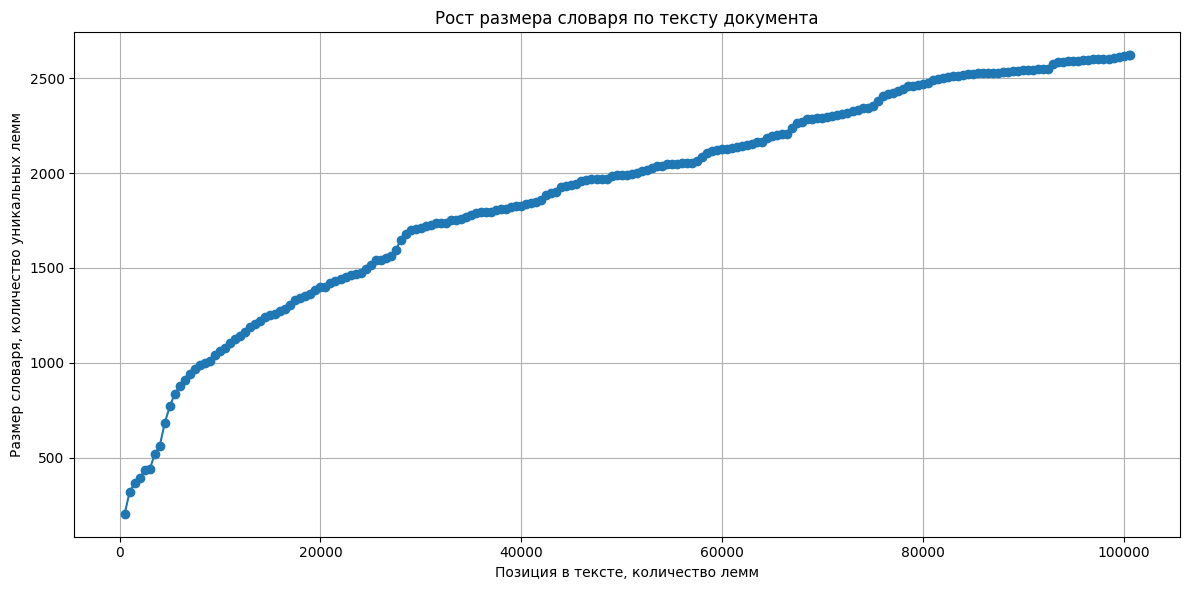

График сохранён в файл: nk_rf_results/06_vocab_growth_plot.png


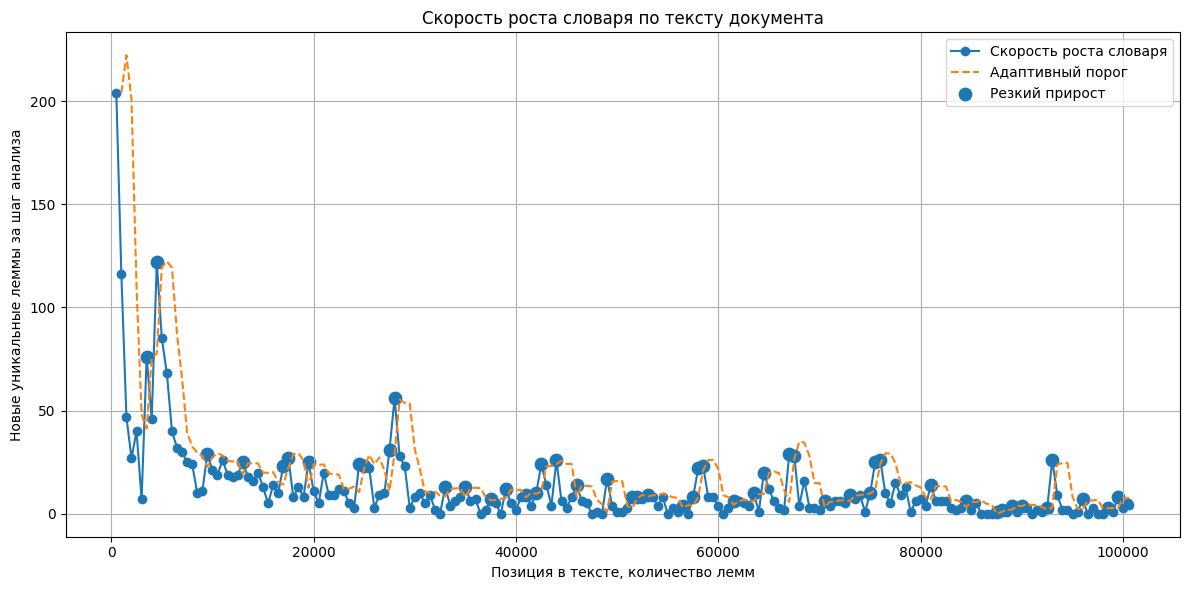

График скорости роста словаря сохранён в файл: nk_rf_results/07_vocab_speed_plot.png

Готово.
Всего лемм в тексте: 100616
Размер итогового словаря: 2621

Примерные места резкого прироста словаря:
     position  vocabulary_size  vocab_increase  position_step  vocab_speed  \
6        3500              517            76.0          500.0         76.0   
8        4500              685           122.0          500.0        122.0   
18       9500             1039            29.0          500.0         29.0   
25      13000             1186            25.0          500.0         25.0   
33      17000             1305            23.0          500.0         23.0   
34      17500             1332            27.0          500.0         27.0   
38      19500             1386            25.0          500.0         25.0   
48      24500             1495            24.0          500.0         24.0   
49      25000             1518            23.0          500.0         23.0   
54      27500           

In [ ]:
clean_text = clean_text_for_analysis(raw_text)

CLEAN_TEXT_FILE.write_text(clean_text, encoding="utf-8")
print(f"Очищенный текст сохранён в файл: {CLEAN_TEXT_FILE}")

lemma_df = tokenize_lemmatize_with_source_positions(raw_text)

lemmas = lemma_df["lemma"].tolist()

LEMMAS_FILE.write_text(" ".join(lemmas), encoding="utf-8")
print(f"Леммы сохранены в файл: {LEMMAS_FILE}")

vocab_growth_df = calculate_vocab_growth(lemmas, step=500)

vocab_growth_df = add_adaptive_threshold(
    vocab_growth_df,
    window=3,
    multiplier=1.0
)

vocab_growth_df.to_csv(
    VOCAB_GROWTH_CSV,
    index=False,
    encoding="utf-8-sig"
)
print(f"Таблица роста словаря сохранена в файл: {VOCAB_GROWTH_CSV}")

jumps_df = find_vocab_jumps(
    vocab_growth_df,
    window=3,
    multiplier=1.0
)

jumps_with_positions_df = add_source_positions_to_jumps(
    jumps_df,
    lemma_df
)

jump_intervals_df = add_jump_intervals_with_source_positions(
    jumps_df,
    lemma_df
)

jump_contexts_df = extract_jump_contexts(
    jumps_df,
    lemma_df,
    raw_text,
    window=40
)

jumps_df.to_csv(
    VOCAB_JUMPS_CSV,
    index=False,
    encoding="utf-8-sig"
)
print(f"Таблица резких приростов словаря сохранена в файл: {VOCAB_JUMPS_CSV}")

VOCAB_JUMPS_WITH_POSITIONS_CSV = OUTPUT_DIR / "05_vocab_jumps_with_source_positions.csv"
JUMP_INTERVALS_CSV = OUTPUT_DIR / "05_vocab_jump_intervals_with_source_positions.csv"

jumps_with_positions_df.to_csv(
    VOCAB_JUMPS_WITH_POSITIONS_CSV,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Таблица скачков с координатами в исходном тексте сохранена в файл: "
    f"{VOCAB_JUMPS_WITH_POSITIONS_CSV}"
)

jump_intervals_df.to_csv(
    JUMP_INTERVALS_CSV,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Интервалы скачков с координатами в исходном тексте сохранены в файл: "
    f"{JUMP_INTERVALS_CSV}"
)

plot_vocab_growth(vocab_growth_df)
print(f"График сохранён в файл: {VOCAB_GROWTH_PNG}")

plot_vocab_speed(vocab_growth_df)

print("\nГотово.")
print(f"Всего лемм в тексте: {len(lemmas)}")
print(f"Размер итогового словаря: {len(set(lemmas))}")
print("\nПримерные места резкого прироста словаря:")
print(jumps_df)

print("\nМеста резких приростов словаря в исходном тексте:")

print(
    jumps_with_positions_df[
        [
            "position",
            "vocabulary_size",
            "vocab_speed",
            "line_number",
            "column_number",
            "original",
            "lemma",
            "line_text"
        ]
    ]
)

print("\nИнтервалы резких приростов словаря в исходном тексте:")

print(
    jump_intervals_df[
        [
            "jump_start_position",
            "jump_end_position",
            "vocab_speed",
            "start_line",
            "start_column",
            "start_word",
            "end_line",
            "end_column",
            "end_word"
        ]
    ]
)

pd.set_option("display.max_colwidth", 500)

print("\nФрагменты текста вокруг скачков:\n")

print(
    jump_contexts_df[
        ["jump_position", "growth_rate", "text_fragment"]
    ]
)

# Доп задание

Нейронная сеть: ChatGPT, модель GPT-5.5 Thinking
Я прикрепляю фрагмент нормативного документа. Сгенерируй искусственный юридический текст, который будет использоваться для сравнения с этим фрагментом по росту количества уникальных слов.

Важно: текст должен быть создан именно на основе прикрепленного фрагмента, а не на основе всей темы налогового законодательства.

Требования:
- размер итогового текста должен быть равен размеру прикрепленного фрагмента;
- сначала проанализируй только прикрепленный фрагмент;
- выдели его тему и основные смысловые блоки;
- затем создай новый текст на ту же тему;
- не копируй исходный фрагмент дословно;
- не используй прямые формулировки из исходного фрагмента без необходимости;
- не добавляй темы, которых нет в прикрепленном фрагменте;
- не пиши про налоговые ставки, налоговую базу, виды налогов, порядок исчисления налогов и налоговую систему в целом, если это не связано с правами налогоплательщиков;
- сохрани формальный юридический стиль;
- объем текста

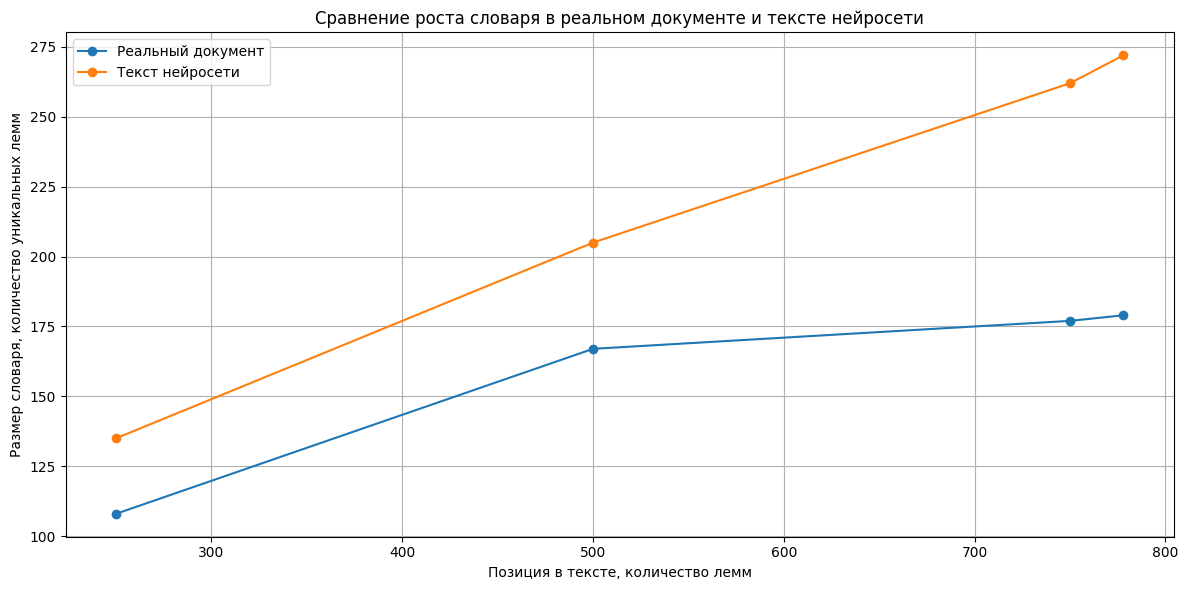

Сравнительный график сохранен в файл: nk_rf_results/11_real_vs_ai_vocab_growth.png

Итоговая статистика:
Реальный документ: 778 лемм, 179 уникальных лемм
Текст нейросети: 778 лемм, 272 уникальных лемм
Разница в размере словаря: -93


In [ ]:
# ============================================================
# ДОПОЛНИТЕЛЬНОЕ ЗАДАНИЕ:
# Сравнение роста словаря в реальном документе и тексте,
# сгенерированном нейронной сетью
# ============================================================

AI_TEXT_FILE = OUTPUT_DIR / "08_ai_generated_text.txt"
REAL_FRAGMENT_FILE = OUTPUT_DIR / "09_real_fragment_text.txt"
COMPARISON_CSV = OUTPUT_DIR / "10_real_vs_ai_vocab_growth.csv"
COMPARISON_PNG = OUTPUT_DIR / "11_real_vs_ai_vocab_growth.png"


# -----------------------------
# 1. Текст, сгенерированный нейронной сетью
# -----------------------------

ai_generated_text = """
Плательщики налогов, сборов и страховых взносов вправе:

1. обращаться в налоговые органы по месту учета за получением безвозмездных сведений, необходимых для исполнения обязанностей и реализации прав, связанных с налоговыми правоотношениями, включая сведения о применимых налогах и сборах, действующих нормативных правовых актах, порядке представления документов, правилах исполнения налоговых обязанностей, правах участников таких отношений, компетенции налоговых органов и полномочиях их должностных лиц, а также получать формы установленных документов и разъяснения по вопросам их заполнения;

2. запрашивать у уполномоченных финансовых органов письменные разъяснения по вопросам применения законодательства о налогах и сборах в пределах их компетенции, в том числе по вопросам применения федеральных, региональных, муниципальных нормативных правовых актов, а также актов, регулирующих соответствующие отношения на отдельных территориях, если такие вопросы отнесены к ведению указанных органов;

3. пользоваться предусмотренными законодательством преимуществами, освобождениями и иными мерами налогового характера при наличии установленных оснований и при соблюдении порядка их применения;

4. обращаться за изменением срока исполнения налоговой обязанности, включая предоставление отсрочки, рассрочки или иного предусмотренного законом механизма переноса срока платежа, если соблюдены условия, установленные законодательством о налогах и сборах;

5. требовать своевременного зачета или возврата денежных средств, учитываемых налоговым органом в отношении соответствующего лица, если такие средства подлежат возврату либо могут быть направлены на исполнение обязанности по уплате налогов, сборов, страховых взносов, пеней, штрафов, процентов или иных платежей в порядке, установленном законом;

5.1) инициировать сверку сумм денежных средств, перечисленных в счет исполнения налоговых обязанностей, а также получать документ, подтверждающий результаты такой сверки;

5.2) на основании направленного запроса получать от налогового органа справки и иные подтверждающие документы о состоянии расчетов, наличии положительного, отрицательного либо нулевого сальдо, принадлежности перечисленных сумм и исполнении обязанности по уплате налогов, сборов, страховых взносов, пеней, штрафов и процентов по данным налогового органа;

6. участвовать в отношениях, регулируемых законодательством о налогах и сборах, лично либо через представителя, полномочия которого оформлены в установленном порядке;

7. давать налоговым органам и их должностным лицам пояснения по вопросам исчисления, декларирования и уплаты обязательных платежей, а также по выводам, изложенным в материалах налогового контроля;

8. присутствовать при проведении выездных мероприятий налогового контроля в случаях, когда такое присутствие допускается законодательством;

9. получать копии актов проверок, решений налоговых органов, уведомлений, требований и иных документов, затрагивающих права и обязанности соответствующего лица;

10. требовать от должностных лиц налоговых органов, а также от иных уполномоченных органов соблюдения законодательства при совершении действий, принятии решений, направлении требований и осуществлении контрольных полномочий;

11. не исполнять требования, решения или иные акты налоговых органов, иных уполномоченных органов и их должностных лиц, если такие требования, решения или акты не соответствуют законодательству;

12. обжаловать акты налоговых органов, действия или бездействие их должностных лиц, а также иные решения, затрагивающие права и законные интересы плательщика, в административном или судебном порядке;

13. требовать соблюдения режима налоговой тайны в отношении сведений, ставших известными налоговым органам и их должностным лицам при осуществлении полномочий;

14. требовать возмещения убытков, причиненных незаконными решениями налоговых органов либо незаконными действиями или бездействием их должностных лиц;

15. участвовать в рассмотрении материалов налоговой проверки, возражать против выводов налогового органа, представлять дополнительные документы, пояснения и доводы в случаях и порядке, предусмотренных законодательством.

1.1. Физические лица, являющиеся налогоплательщиками, вправе представлять документы и сведения в налоговые органы, а также получать от налоговых органов документы и сведения через многофункциональные центры предоставления государственных и муниципальных услуг, если такая возможность организована на основании решений компетентных органов субъекта Российской Федерации и если законодательством предусмотрено соответствующее взаимодействие через указанные центры.

При передаче физическим лицом документов или сведений через многофункциональный центр днем их представления в налоговый орган считается день приема таких документов или сведений многофункциональным центром. В подтверждение приема физическому лицу выдается расписка либо иной документ, удостоверяющий факт передачи документов или сведений.

1.2. Физические лица, зарегистрированные в единой системе идентификации и аутентификации, вправе использовать единый портал государственных и муниципальных услуг для направления в налоговые органы документов и сведений в электронной форме, а также для получения от налоговых органов документов и сведений, включая сведения, относящиеся к налоговой тайне, если такой способ взаимодействия предусмотрен законодательством и если налогоплательщик направил соответствующее уведомление о необходимости получения документов через личный кабинет на едином портале.

Документы и сведения, которые могут направляться физическими лицами в налоговые органы посредством единого портала государственных и муниципальных услуг, а также документы и сведения, которые налоговые органы вправе направлять физическим лицам через личный кабинет на указанном портале, определяются законодательством либо утвержденным уполномоченным органом перечнем.

При направлении физическим лицом документов или сведений в электронной форме с использованием единого портала государственных и муниципальных услуг днем их представления считается день направления таких документов или сведений в налоговый орган через соответствующий электронный сервис. Информация о дате направления размещается в личном кабинете пользователя на едином портале.

Физическое лицо вправе прекратить получение документов и сведений от налогового органа через личный кабинет на едином портале государственных и муниципальных услуг путем направления в налоговый орган электронного уведомления о прекращении такого способа получения документов. Получение документов и сведений прекращается по истечении установленного срока со дня представления указанного уведомления.

Физическое лицо, ранее отказавшееся от получения документов и сведений через единый портал государственных и муниципальных услуг, вправе повторно направить уведомление о необходимости получения документов с использованием указанного портала. В таком случае налоговый орган возобновляет направление документов и сведений через личный кабинет в пределах порядка, установленного законодательством.

Уведомления, направляемые через единый портал государственных и муниципальных услуг, подписываются электронной подписью, применяемой в инфраструктуре электронного взаимодействия при предоставлении государственных и муниципальных услуг, если иное не предусмотрено законодательством.

Формы уведомлений, правила их заполнения и электронные форматы представления утверждаются уполномоченным федеральным органом исполнительной власти по согласованию с органом, осуществляющим функции в сфере информационных технологий и нормативного регулирования электронного взаимодействия.

2. Плательщики налогов, сборов и страховых взносов имеют также иные права, предусмотренные законодательством о налогах и сборах и иными федеральными законами.

3. Права, предоставленные налогоплательщикам, применяются также к плательщикам сборов и плательщикам страховых взносов, если иное не вытекает из существа соответствующих отношений или специальных норм законодательства.

4. Участник договора инвестиционного товарищества вправе защищать свои права путем обжалования актов налоговых органов, а также действий или бездействия их должностных лиц, если такие акты, действия или бездействие затрагивают его законные интересы.

5. Плательщикам налогов, сборов и страховых взносов гарантируется защита их прав и законных интересов в административном и судебном порядке. Порядок такой защиты определяется законодательством о налогах и сборах, процессуальным законодательством и иными федеральными законами.

6. Реализация прав плательщиков обеспечивается обязанностями налоговых органов, иных уполномоченных органов и их должностных лиц. Указанные органы и должностные лица обязаны действовать в пределах предоставленных полномочий, соблюдать установленные процедуры, обеспечивать возможность представления объяснений, возражений и документов, а также не препятствовать законному осуществлению прав участников налоговых правоотношений.

7. Невыполнение либо ненадлежащее выполнение должностными лицами обязанностей, направленных на обеспечение прав плательщиков налогов, сборов и страховых взносов, влечет ответственность в случаях и порядке, установленных федеральными законами.

8. Защита нарушенного права может осуществляться путем подачи жалобы в вышестоящий налоговый орган, обращения в иной уполномоченный орган, направления заявления в суд, а также использования иных предусмотренных законом способов восстановления нарушенных прав и законных интересов.

"""
print("Нейронная сеть: ChatGPT, модель GPT-5.5 Thinking")
print('''Я прикрепляю фрагмент нормативного документа. Сгенерируй искусственный юридический текст, который будет использоваться для сравнения с этим фрагментом по росту количества уникальных слов.

Важно: текст должен быть создан именно на основе прикрепленного фрагмента, а не на основе всей темы налогового законодательства.

Требования:
- размер итогового текста должен быть равен размеру прикрепленного фрагмента;
- сначала проанализируй только прикрепленный фрагмент;
- выдели его тему и основные смысловые блоки;
- затем создай новый текст на ту же тему;
- не копируй исходный фрагмент дословно;
- не используй прямые формулировки из исходного фрагмента без необходимости;
- не добавляй темы, которых нет в прикрепленном фрагменте;
- не пиши про налоговые ставки, налоговую базу, виды налогов, порядок исчисления налогов и налоговую систему в целом, если это не связано с правами налогоплательщиков;
- сохрани формальный юридический стиль;
- объем текста сделай примерно таким же, как у прикрепленного фрагмента;
- допускается структура с пунктами и подпунктами;
- выведи только сгенерированный искусственный текст без пояснений.

Содержательно текст должен быть посвящен тем же вопросам, что и прикрепленный фрагмент: правам налогоплательщиков и иных плательщиков,
получению информации и документов, взаимодействию с налоговыми органами, использованию представителей, участию в налоговых проверках,
обжалованию актов и действий налоговых органов, налоговой тайне, электронному взаимодействию через портал государственных услуг,
обращению через многофункциональные центры, а также административной и судебной защите прав.''')

AI_TEXT_FILE.write_text(ai_generated_text, encoding="utf-8")
print(f"Сгенерированный нейросетью текст сохранен в файл: {AI_TEXT_FILE}")


# -----------------------------
# 2. Берем фрагмент реального документа от одной фразы до другой
# -----------------------------

# Берем исходный смысловой текст, который был сохранен в основном задании.
# Лучше брать RAW_TEXT_FILE, потому что в нем текст еще читаемый:
# с предложениями, абзацами и пунктуацией.
real_raw_text = RAW_TEXT_FILE.read_text(encoding="utf-8")


# Указываем фразу, с которой должен начинаться фрагмент.
# Важно: фразу нужно писать так, как она встречается в файле 01_raw_text.txt.
start_phrase = "Налогоплательщики имеют право"


# Указываем фразу, на которой фрагмент должен закончиться.
# Эта фраза тоже должна реально встречаться в файле 01_raw_text.txt.
end_phrase = "Налогоплательщики обязаны"


# Ищем позицию начала фрагмента
start_index = real_raw_text.find(start_phrase)

# Ищем позицию конца фрагмента
end_index = real_raw_text.find(end_phrase, start_index)


# Проверяем, что обе фразы найдены
if start_index == -1:
    raise ValueError(f"Начальная фраза не найдена в тексте: {start_phrase}")

if end_index == -1:
    raise ValueError(f"Конечная фраза не найдена в тексте после начальной фразы: {end_phrase}")


# Чтобы конечная фраза тоже вошла во фрагмент,
# прибавляем ее длину к позиции конца
end_index = end_index + len(end_phrase)


# Вырезаем фрагмент
real_fragment_text = real_raw_text[start_index:end_index].strip()


# Сохраняем фрагмент в отдельный файл
REAL_FRAGMENT_FILE.write_text(real_fragment_text, encoding="utf-8")

print(f"Фрагмент реального документа сохранен в файл: {REAL_FRAGMENT_FILE}")
print(f"Начальная фраза: {start_phrase}")
print(f"Конечная фраза: {end_phrase}")
print(f"Размер фрагмента в символах: {len(real_fragment_text)}")
print(f"Размер фрагмента в словах примерно: {len(real_fragment_text.split())}")


# -----------------------------
# 3. Одинаковая обработка обоих текстов
# -----------------------------

real_fragment_lemma_df = tokenize_lemmatize_with_source_positions(real_fragment_text)
ai_lemma_df = tokenize_lemmatize_with_source_positions(ai_generated_text)

real_fragment_lemmas = real_fragment_lemma_df["lemma"].tolist()
ai_lemmas = ai_lemma_df["lemma"].tolist()

# Чтобы сравнение было корректнее, ограничим оба текста одинаковым количеством лемм.
min_len = min(len(real_fragment_lemmas), len(ai_lemmas))

real_fragment_lemmas = real_fragment_lemmas[:min_len]
ai_lemmas = ai_lemmas[:min_len]

print(f"Количество лемм в реальном фрагменте: {len(real_fragment_lemmas)}")
print(f"Количество лемм в тексте нейросети: {len(ai_lemmas)}")


# -----------------------------
# 4. Расчет роста словаря
# -----------------------------

real_vocab_growth = calculate_vocab_growth(real_fragment_lemmas, step=250)
ai_vocab_growth = calculate_vocab_growth(ai_lemmas, step=250)

real_vocab_growth["text_type"] = "Реальный документ"
ai_vocab_growth["text_type"] = "Текст нейросети"

comparison_df = pd.concat(
    [real_vocab_growth, ai_vocab_growth],
    ignore_index=True
)

comparison_df.to_csv(
    COMPARISON_CSV,
    index=False,
    encoding="utf-8-sig"
)

print(f"Таблица сравнения сохранена в файл: {COMPARISON_CSV}")


# -----------------------------
# 5. Построение сравнительного графика
# -----------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    real_vocab_growth["position"],
    real_vocab_growth["vocabulary_size"],
    marker="o",
    label="Реальный документ"
)

plt.plot(
    ai_vocab_growth["position"],
    ai_vocab_growth["vocabulary_size"],
    marker="o",
    label="Текст нейросети"
)

plt.title("Сравнение роста словаря в реальном документе и тексте нейросети")
plt.xlabel("Позиция в тексте, количество лемм")
plt.ylabel("Размер словаря, количество уникальных лемм")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig(COMPARISON_PNG, dpi=300)
plt.show()

print(f"Сравнительный график сохранен в файл: {COMPARISON_PNG}")


# -----------------------------
# 6. Краткая статистика
# -----------------------------

real_final_vocab = len(set(real_fragment_lemmas))
ai_final_vocab = len(set(ai_lemmas))

print("\nИтоговая статистика:")
print(f"Реальный документ: {len(real_fragment_lemmas)} лемм, {real_final_vocab} уникальных лемм")
print(f"Текст нейросети: {len(ai_lemmas)} лемм, {ai_final_vocab} уникальных лемм")
print(f"Разница в размере словаря: {real_final_vocab - ai_final_vocab}")